# EDA y verificación de calidad de la base simulada

En este notebook hacemos un EDA completo de la base simulada y verificamos que
reproduce lo que planteamos en la Primera entrega (20%-25% de riesgo "malo" y
la dirección de las relaciones documentadas). Las Secciones 1 a 6 trabajan
sobre `credito_simulado_base.csv`, la versión sin faltantes; la Sección 7
revisa la calidad de `credito_simulado_con_faltantes.csv`, que es la base de
trabajo del modelamiento, y define las transformaciones que necesita. El
`Pipeline` y las líneas base de la Sección 7.2 están en
`03_Pipeline_particion_lineas_base.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/simulado/credito_simulado_base.csv")
print(df.shape)
df.head()


(6500, 13)


,id,edad,genero,tipo_ocupacion,tipo_vivienda,nivel_ahorro,saldo_categoria,saldo_cuenta_cop,monto_credito_cop,plazo_meses,proposito_credito,estado_pago_previo,riesgo
0,1,37,F,formal_no_calificado,arrendada,bajo,medio,636000.0,5494000.0,51,electrodomesticos,mora_severa,bueno
1,2,42,F,formal_no_calificado,arrendada,bajo,sin_cuenta,0.0,9976000.0,30,remodelacion,mora_severa,bueno
2,3,34,M,informal,arrendada,bajo,alto,3729000.0,3585000.0,27,libre_inversion,mora_severa,bueno
3,4,33,M,informal,familiar,bajo,sin_cuenta,0.0,2670000.0,9,vehiculo,mora_severa,malo
4,5,44,M,alta_calificacion,familiar,bajo,medio,326000.0,1586000.0,18,educacion,sin_creditos_previos,bueno


## 1. Estructura general

Empezamos revisando tipos de datos y duplicados antes que cualquier otra
cosa, porque un error de tipo o un registro duplicado distorsiona cualquier
estadística que calculemos después.

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  6500 non-null   int64  
 1   edad                6500 non-null   int64  
 2   genero              6500 non-null   str    
 3   tipo_ocupacion      6500 non-null   str    
 4   tipo_vivienda       6500 non-null   str    
 5   nivel_ahorro        6500 non-null   str    
 6   saldo_categoria     6500 non-null   str    
 7   saldo_cuenta_cop    6500 non-null   float64
 8   monto_credito_cop   6500 non-null   float64
 9   plazo_meses         6500 non-null   int64  
 10  proposito_credito   6500 non-null   str    
 11  estado_pago_previo  6500 non-null   str    
 12  riesgo              6500 non-null   str    
dtypes: float64(2), int64(3), str(8)
memory usage: 660.3 KB


In [3]:
# Duplicados: por fila completa y por el identificador `id`
print("Filas duplicadas (todas las columnas):", df.duplicated().sum())
print("IDs duplicados:", df["id"].duplicated().sum())
print("IDs únicos:", df["id"].nunique(), "de", len(df), "registros")
print("Valores faltantes en toda la base:", df.isna().sum().sum(),
      "(esperado: 0, esta es la versión sin faltantes)")


Filas duplicadas (todas las columnas): 0
IDs duplicados: 0
IDs únicos: 6500 de 6500 registros
Valores faltantes en toda la base: 0 (esperado: 0, esta es la versión sin faltantes)


## 2. Outliers (valores atípicos)

Usamos el criterio IQR (rango intercuartílico) en vez de una regla basada en
z-score, porque las variables numéricas de esta base (`monto_credito_cop`,
`saldo_cuenta_cop`) son log-normales por diseño, tienen cola larga hacia la
derecha. Un criterio de z-score asume implícitamente simetría, y con datos
así de sesgados terminaría marcando como "atípicos" un montón de valores
altos que en realidad son parte normal de la distribución. El IQR es más
robusto frente a esa asimetría porque se basa en percentiles y no en la
media.

In [4]:
def resumen_outliers_iqr(serie, k=1.5):
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - k * iqr, q3 + k * iqr
    atipicos = (s < lim_inf) | (s > lim_sup)
    return {
        "n_validos": len(s), "lim_inf": lim_inf, "lim_sup": lim_sup,
        "n_atipicos": atipicos.sum(), "%_atipicos": round(atipicos.mean() * 100, 2),
    }

num_cols = ["edad", "saldo_cuenta_cop", "monto_credito_cop", "plazo_meses"]
outliers_df = pd.DataFrame({c: resumen_outliers_iqr(df[c]) for c in num_cols}).T
outliers_df


,n_validos,lim_inf,lim_sup,n_atipicos,%_atipicos
edad,6500.0,6.0,62.0,196.0,3.02
saldo_cuenta_cop,6500.0,-714000.0,1190000.0,570.0,8.77
monto_credito_cop,6500.0,-3922375.0,12744625.0,333.0,5.12
plazo_meses,6500.0,-10.5,49.5,172.0,2.65


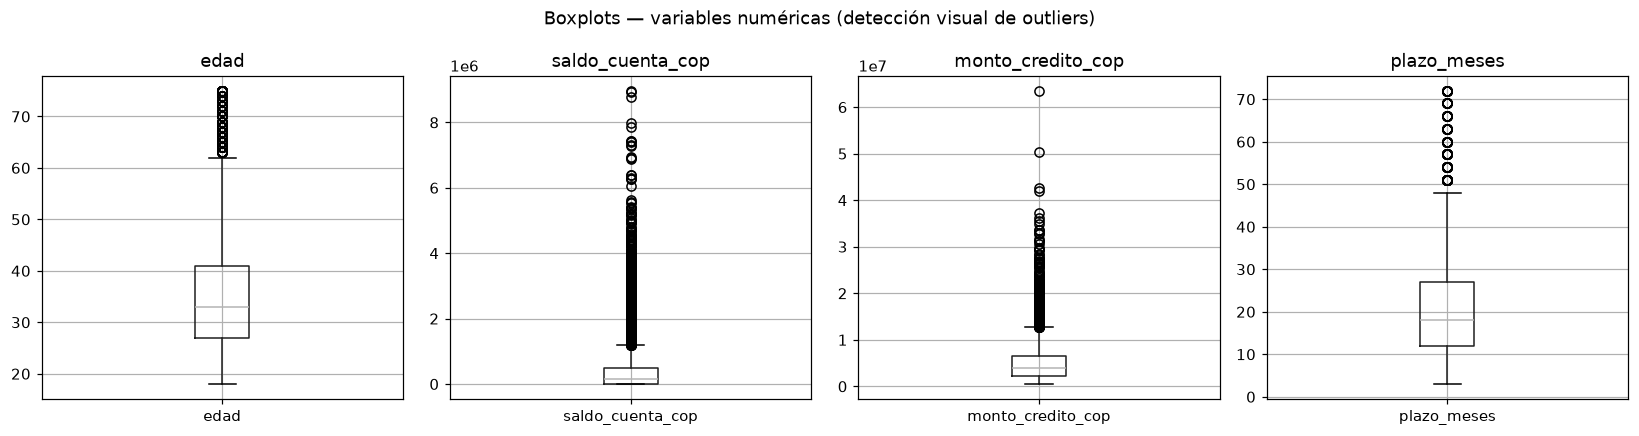

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
fig.suptitle("Boxplots — variables numéricas (detección visual de outliers)")
fig.tight_layout()
plt.show()


**Cómo leer los outliers.** Los valores que el criterio IQR marca como
atípicos en `monto_credito_cop` y `saldo_cuenta_cop` son, en su mayoría,
consecuencia esperada de la forma log-normal de estas variables, es decir
créditos de monto alto pero perfectamente legítimos, no errores de captura, así
que no recomendamos eliminarlos sin más. `edad` y `plazo_meses` están acotadas
por diseño (entre 18 y 75 años, y entre 3 y 72 meses), así que sus outliers, si
aparecen, son marginales.

## 3. EDA univariado

Separamos numéricas de categóricas porque cada tipo necesita una
visualización distinta, histograma para unas y gráfico de barras de
proporciones para otras, y también una lectura distinta: forma de la
distribución en un caso, balance entre categorías en el otro.

In [6]:
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
edad,6500.0,3.547000e+01,1.104853e+01,18.0,27.0,33.0,41.0,75.0
saldo_cuenta_cop,6500.0,4.156558e+05,7.962407e+05,0.0,0.0,144000.0,476000.0,8968000.0
monto_credito_cop,6500.0,5.118505e+06,4.251611e+06,500000.0,2327750.0,3973000.0,6494500.0,63522000.0
plazo_meses,6500.0,2.090815e+01,1.139559e+01,3.0,12.0,18.0,27.0,72.0


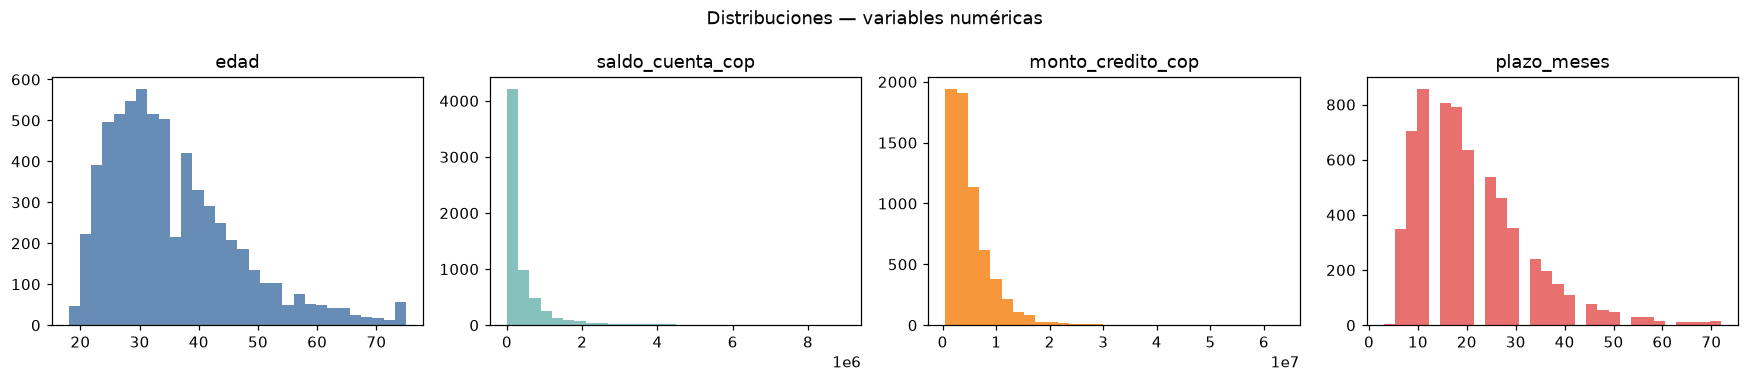

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
colors = ["#4C78A8", "#72B7B2", "#F58518", "#E45756"]
for ax, col, color in zip(axes, num_cols, colors):
    ax.hist(df[col], bins=30, color=color, alpha=0.85)
    ax.set_title(col)
fig.suptitle("Distribuciones — variables numéricas")
fig.tight_layout()
plt.show()


Revisamos las categóricas en proporciones y no en conteos absolutos, porque
con 6.500 registros los conteos son menos fáciles de leer que las proporciones
a la hora de juzgar si una categoría está sub-representada, algo que nos va a
servir para decidir, en la Sección 7.2, si alguna categoría necesita
agruparse antes de la codificación one-hot.

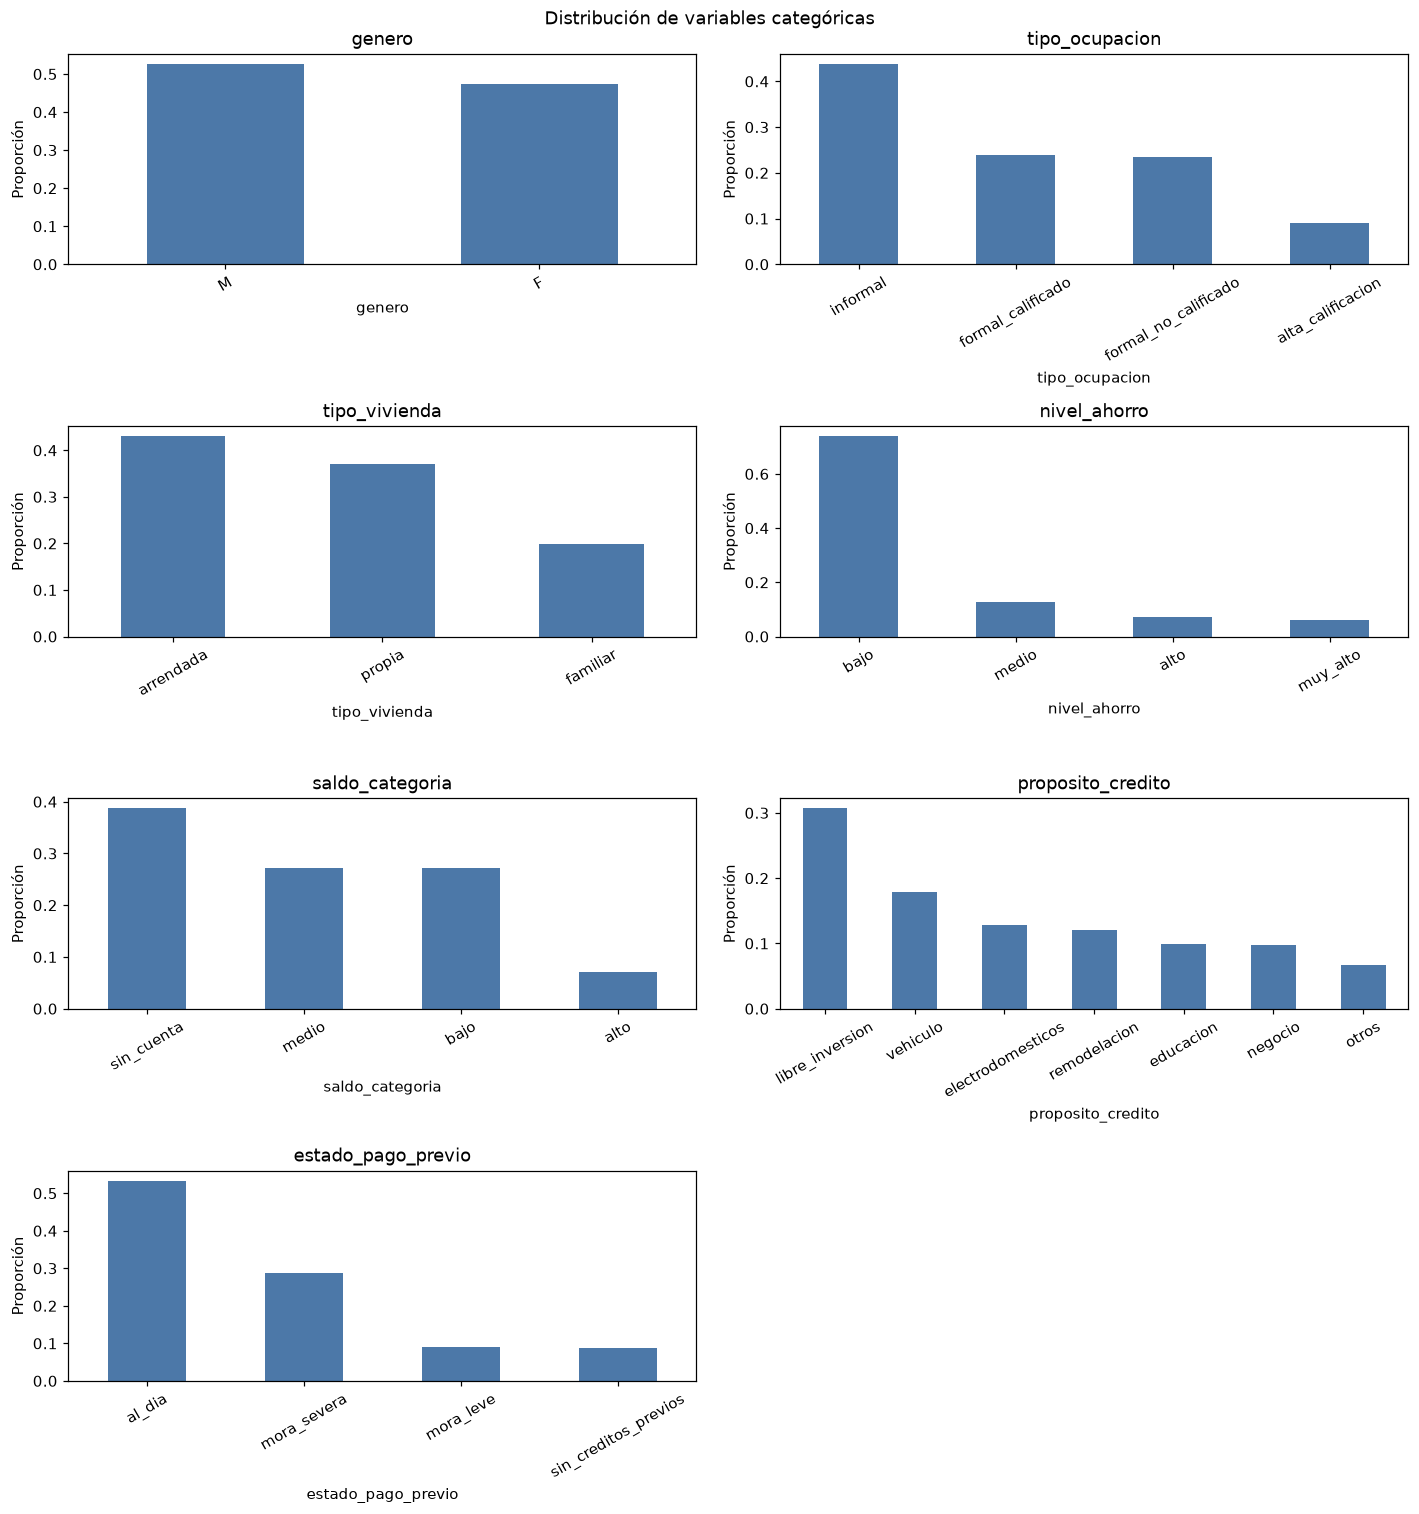

In [8]:
cat_cols = ["genero", "tipo_ocupacion", "tipo_vivienda", "nivel_ahorro",
            "saldo_categoria", "proposito_credito", "estado_pago_previo"]

fig, axes = plt.subplots(4, 2, figsize=(13, 14))
axes = axes.ravel()
for ax, col in zip(axes, cat_cols):
    df[col].value_counts(normalize=True).plot(kind="bar", ax=ax, color="#4C78A8")
    ax.set_title(col)
    ax.set_ylabel("Proporción")
    ax.tick_params(axis="x", rotation=30)
axes[-1].axis("off")
fig.suptitle("Distribución de variables categóricas")
fig.tight_layout()
plt.show()


## 4. EDA bivariado: relación con la variable objetivo

Miramos cada predictor contra `riesgo` antes de ponernos a modelar porque esta
es la evidencia directa de que las variables sí tienen poder predictivo, lo
cual justifica usarlas en el modelo, y sobre todo porque acá es donde de
verdad verificamos que la simulación reprodujo las relaciones que
documentamos en la Primera entrega. No basta con haberlas programado en
`generar_datos_simulados.py`, hay que confirmarlas en los datos que
efectivamente salieron.

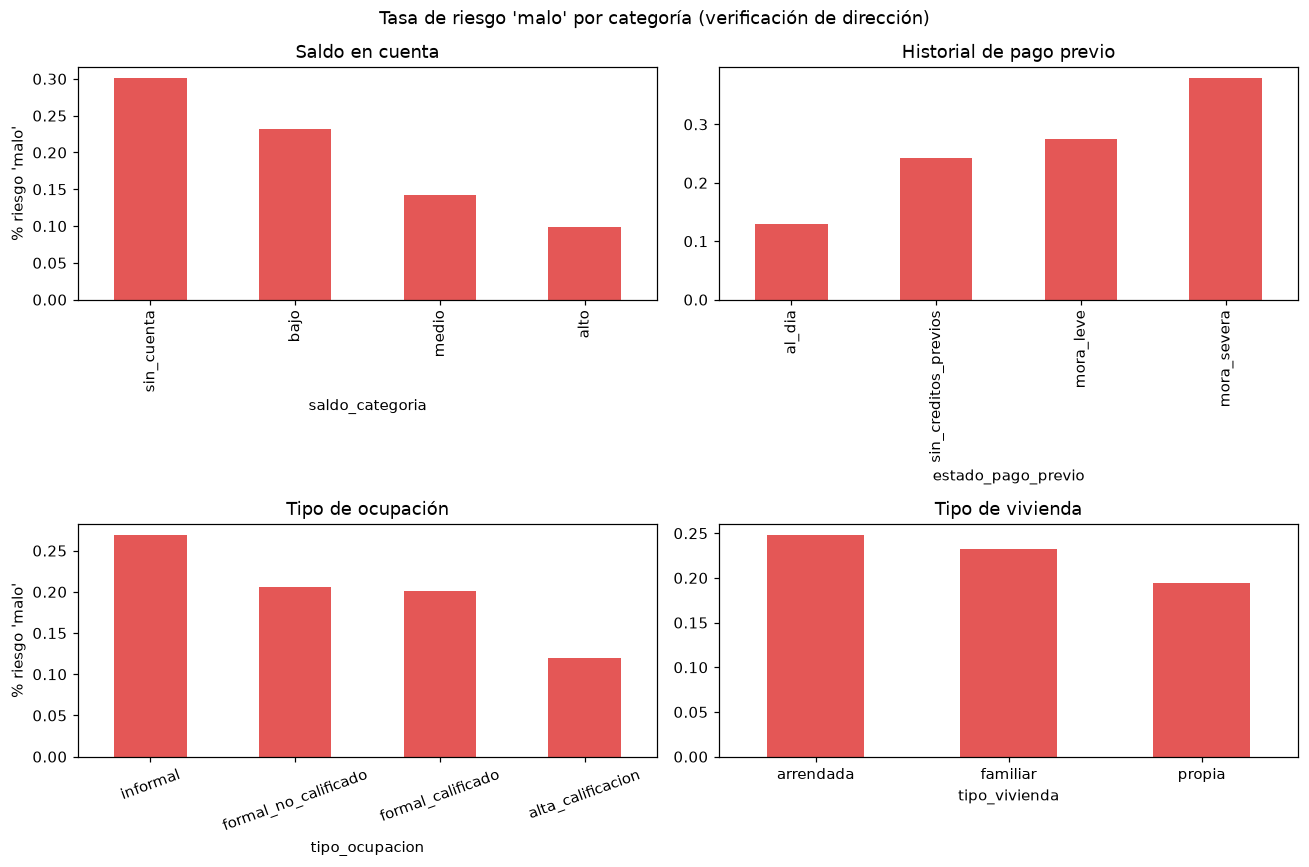

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

t_saldo = df.groupby("saldo_categoria")["riesgo"].apply(lambda s: (s == "malo").mean())
t_saldo = t_saldo.reindex(["sin_cuenta", "bajo", "medio", "alto"])
t_saldo.plot(kind="bar", ax=axes[0, 0], color="#E45756")
axes[0, 0].set_title("Saldo en cuenta")
axes[0, 0].set_ylabel("% riesgo 'malo'")

t_pago = df.groupby("estado_pago_previo")["riesgo"].apply(lambda s: (s == "malo").mean())
t_pago = t_pago.reindex(["al_dia", "sin_creditos_previos", "mora_leve", "mora_severa"])
t_pago.plot(kind="bar", ax=axes[0, 1], color="#E45756")
axes[0, 1].set_title("Historial de pago previo")

t_ocup = df.groupby("tipo_ocupacion")["riesgo"].apply(lambda s: (s == "malo").mean())
t_ocup = t_ocup.reindex(["informal", "formal_no_calificado", "formal_calificado", "alta_calificacion"])
t_ocup.plot(kind="bar", ax=axes[1, 0], color="#E45756")
axes[1, 0].set_title("Tipo de ocupación")
axes[1, 0].set_ylabel("% riesgo 'malo'")
axes[1, 0].tick_params(axis="x", rotation=20)

t_viv = df.groupby("tipo_vivienda")["riesgo"].apply(lambda s: (s == "malo").mean())
t_viv.plot(kind="bar", ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Tipo de vivienda")
axes[1, 1].tick_params(axis="x", rotation=0)

fig.suptitle("Tasa de riesgo 'malo' por categoría (verificación de dirección)")
fig.tight_layout()
plt.show()

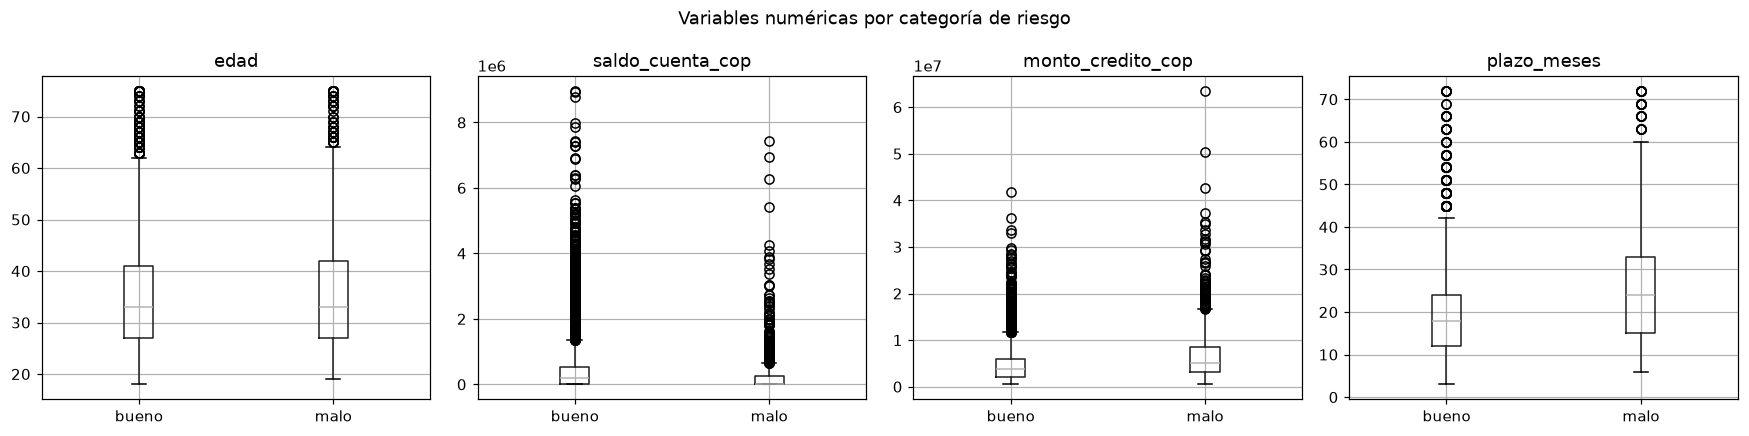

In [10]:
# Numéricas: boxplot de cada variable, separado por riesgo
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by="riesgo", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Variables numéricas por categoría de riesgo")
fig.tight_layout()
plt.show()


## 5. Correlaciones entre variables numéricas

Revisamos correlaciones antes de modelar porque, aunque una correlación alta
entre dos predictores (multicolinealidad) no rompe un SVM de la misma forma
en que rompería una regresión lineal, vale la pena tenerla documentada. En
particular, la correlación entre plazo y monto la diseñamos a propósito para
reproducir la del original (0.62 entre `duration` y `credit_amount`; ver
Sección 3.3 del notebook 01). Las demás parejas deberían tener correlación
cercana a cero, porque se generaron de forma independiente.

In [11]:
corr = df[num_cols].corr()
corr


,edad,saldo_cuenta_cop,monto_credito_cop,plazo_meses
edad,1.000000,-0.005093,0.025997,0.001743
saldo_cuenta_cop,-0.005093,1.000000,-0.009145,-0.016211
monto_credito_cop,0.025997,-0.009145,1.000000,0.602684
plazo_meses,0.001743,-0.016211,0.602684,1.000000


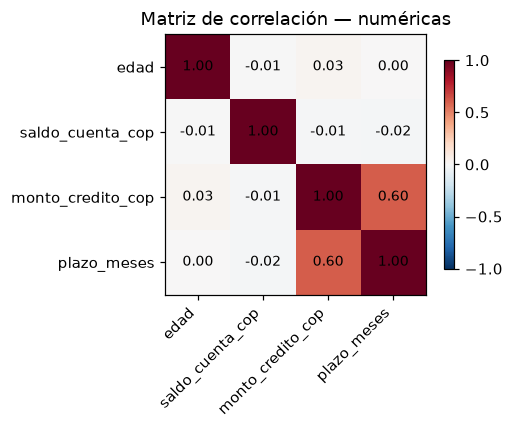

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, shrink=0.8)
ax.set_title("Matriz de correlación — numéricas")
fig.tight_layout()
plt.show()


## 6. Verificación de que la simulación reproduce lo planeado

Contrastamos contra un criterio de aceptación que fijamos de antemano en la
Primera entrega: un rango de 20%-25% de "malo" y cuatro relaciones monótonas
específicas. Es la diferencia entre mirar los datos y verificar que cumplen lo
que prometimos, que es justo el criterio central de la rúbrica de la Segunda
entrega para la consolidación de datos. La monotonicidad se evalúa ordenando
las categorías de menor a mayor riesgo esperado y exigiendo que la tasa de
"malo" crezca estrictamente.

In [13]:
prop_riesgo = df["riesgo"].value_counts(normalize=True)
cumple_balance = 0.20 <= prop_riesgo["malo"] <= 0.25
print("Balance de clases:", prop_riesgo.round(4).to_dict())
print(f"¿Cumple el rango planeado (20%-25% de 'malo')?: {cumple_balance}")


Balance de clases: {'bueno': 0.7754, 'malo': 0.2246}
¿Cumple el rango planeado (20%-25% de 'malo')?: True


In [14]:
def es_creciente(serie):
    """True si la tasa de "malo" crece estrictamente en el orden dado."""
    return bool(np.all(np.diff(serie.to_numpy()) > 0))

def tasa_malo(por):
    return df.groupby(por, observed=True)["riesgo"].apply(lambda s: (s == "malo").mean())

t_saldo_orden = t_saldo.reindex(["alto", "medio", "bajo", "sin_cuenta"])  # menor -> mayor riesgo
t_monto = tasa_malo(pd.qcut(df["monto_credito_cop"], 4, labels=["Q1", "Q2", "Q3", "Q4"]))
t_plazo = tasa_malo(pd.qcut(df["plazo_meses"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop"))

verificacion = pd.DataFrame({
    "relación esperada": [
        "saldo: alto < medio < bajo < sin cuenta",
        "historial: al día < sin créditos < mora leve < mora severa",
        "monto: Q1 < Q2 < Q3 < Q4",
        "plazo: Q1 < Q2 < Q3 < Q4",
    ],
    "tasas de 'malo'": [", ".join(f"{v:.1%}" for v in t)
                        for t in [t_saldo_orden, t_pago, t_monto, t_plazo]],
    "¿monótona?": [es_creciente(t) for t in [t_saldo_orden, t_pago, t_monto, t_plazo]],
})
verificacion

,relación esperada,tasas de 'malo',¿monótona?
0,saldo: alto < medio < bajo < sin cuenta,"9.8%, 14.2%, 23.2%, 30.1%",True
1,historial: al día < sin créditos < mora leve <...,"13.0%, 24.2%, 27.5%, 37.9%",True
2,monto: Q1 < Q2 < Q3 < Q4,"13.7%, 18.5%, 24.4%, 33.2%",True
3,plazo: Q1 < Q2 < Q3 < Q4,"14.4%, 18.7%, 25.0%, 35.3%",True


## 7. Calidad de la versión con faltantes (base de trabajo)

El modelamiento no se hace sobre la base limpia sino sobre
`credito_simulado_con_faltantes.csv`, que agrega faltantes y ruido de medición
para que el preprocesamiento sea genuino. Antes de construir el `Pipeline`
revisamos tres cosas: cuánto falta y dónde, si el mecanismo de faltantes es el
que diseñamos, y qué tan grande es el ruido. De eso se derivan las
transformaciones de la Sección 7.2.

In [15]:
df_na = pd.read_csv("../data/simulado/credito_simulado_con_faltantes.csv")
assert (df_na["id"] == df["id"]).all()

faltantes = pd.DataFrame({
    "n_faltantes": df_na.isna().sum(),
    "%_faltantes": (df_na.isna().mean() * 100).round(2),
}).query("n_faltantes > 0")
print("Filas con al menos un faltante:", f"{df_na.isna().any(axis=1).mean():.1%}")
faltantes

Filas con al menos un faltante: 22.0%


,n_faltantes,%_faltantes
edad,216,3.32
tipo_ocupacion,281,4.32
nivel_ahorro,325,5.00
saldo_cuenta_cop,311,4.78
monto_credito_cop,245,3.77
plazo_meses,191,2.94


Cada columna afectada tiene entre 3% y 5% de faltantes. Como se reparten en
seis columnas distintas, cerca de una de cada cinco filas tiene al menos un
hueco: eliminar filas incompletas descartaría ~20% de la base, así que
imputamos.

El saldo en cuenta se diseñó con faltantes MAR (dependientes de otra
variable): solo puede faltar en clientes que sí tienen cuenta, y falta más en
saldos bajos, simulando el subreporte típico de saldos pequeños. Lo
verificamos contra la base limpia, donde sí conocemos el valor real:

In [16]:
falta_saldo = df_na["saldo_cuenta_cop"].isna()
con_cuenta = df["saldo_categoria"] != "sin_cuenta"
bajo_mediana = df["saldo_cuenta_cop"] < df.loc[con_cuenta, "saldo_cuenta_cop"].median()

print("Saldos faltantes en clientes sin cuenta:", int((falta_saldo & ~con_cuenta).sum()))
print(f"% faltante en saldos bajos (con cuenta): {falta_saldo[con_cuenta & bajo_mediana].mean():.1%}")
print(f"% faltante en saldos altos (con cuenta): {falta_saldo[con_cuenta & ~bajo_mediana].mean():.1%}")

# Ruido de medición: registros que cambian entre la base limpia y la de trabajo
for col in ["edad", "saldo_cuenta_cop", "monto_credito_cop", "plazo_meses"]:
    observado = df_na[col].notna()
    cambio = df_na.loc[observado, col] != df.loc[observado, col]
    rel = ((df_na.loc[observado, col] - df.loc[observado, col]).abs()
           / df.loc[observado, col].replace(0, np.nan))[cambio]
    print(f"{col:>18}: {cambio.mean():.1%} de registros con ruido, "
          f"cambio relativo mediano {rel.median():.1%}" if cambio.any() else f"{col:>18}: sin ruido")

Saldos faltantes en clientes sin cuenta:

 0
% faltante en saldos bajos (con cuenta): 12.1%
% faltante en saldos altos (con cuenta): 3.5%
              edad: 1.5% de registros con ruido, cambio relativo mediano 2.9%
  saldo_cuenta_cop: 1.9% de registros con ruido, cambio relativo mediano 1.6%
 monto_credito_cop: 3.0% de registros con ruido, cambio relativo mediano 1.4%
       plazo_meses: sin ruido


Por último, revisamos en la base de trabajo los otros problemas de calidad que
pueden aparecer en datos de solicitudes de crédito: **duplicados**,
**categorías inválidas** (errores de digitación), **valores fuera de rango** e
**inconsistencias entre columnas**. Cada regla se evalúa solo sobre los valores
observados (los faltantes se cuentan aparte).

In [17]:
CATEGORIAS_VALIDAS = {
    "genero": {"M", "F"},
    "tipo_ocupacion": {"informal", "formal_no_calificado", "formal_calificado", "alta_calificacion"},
    "tipo_vivienda": {"propia", "arrendada", "familiar"},
    "nivel_ahorro": {"bajo", "medio", "alto", "muy_alto"},
    "saldo_categoria": {"sin_cuenta", "bajo", "medio", "alto"},
    "proposito_credito": {"libre_inversion", "vehiculo", "electrodomesticos", "remodelacion",
                          "educacion", "negocio", "otros"},
    "estado_pago_previo": {"sin_creditos_previos", "al_dia", "mora_leve", "mora_severa"},
    "riesgo": {"bueno", "malo"},
}
edad, plazo = df_na["edad"].dropna(), df_na["plazo_meses"].dropna()  # solo valores observados
reglas = {
    "Filas duplicadas (sin contar id)": df_na.drop(columns="id").duplicated().sum(),
    "IDs duplicados": df_na["id"].duplicated().sum(),
    **{f"Categoría inválida en {c}": (~df_na[c].dropna().isin(v)).sum() for c, v in CATEGORIAS_VALIDAS.items()},
    "Edad fuera de [18, 75] o no entera": ((edad < 18) | (edad > 75) | (edad % 1 != 0)).sum(),
    "Plazo fuera de [3, 72] o no múltiplo de 3": ((plazo < 3) | (plazo > 72) | (plazo % 3 != 0)).sum(),
    "Monto fuera de [0.5, 80] millones COP": ((df_na["monto_credito_cop"] < 500_000)
                                              | (df_na["monto_credito_cop"] > 80_000_000)).sum(),
    "Saldo negativo": (df_na["saldo_cuenta_cop"] < 0).sum(),
    "Saldo > 0 con 'sin_cuenta'": ((df_na["saldo_categoria"] == "sin_cuenta")
                                   & (df_na["saldo_cuenta_cop"] > 0)).sum(),
    "Saldo = 0 con cuenta": ((df_na["saldo_categoria"] != "sin_cuenta")
                             & (df_na["saldo_cuenta_cop"] == 0)).sum(),
}
calidad = pd.DataFrame({"registros que la incumplen": reglas})
calidad["¿OK?"] = calidad["registros que la incumplen"] == 0
calidad

,registros que la incumplen,¿OK?
Filas duplicadas (sin contar id),0,True
IDs duplicados,0,True
Categoría inválida en genero,0,True
Categoría inválida en tipo_ocupacion,0,True
Categoría inválida en tipo_vivienda,0,True
Categoría inválida en nivel_ahorro,0,True
Categoría inválida en saldo_categoria,0,True
Categoría inválida en proposito_credito,0,True
Categoría inválida en estado_pago_previo,0,True
Categoría inválida en riesgo,0,True


Ninguna regla se incumple: no hay duplicados, categorías inválidas, valores
fuera de rango ni contradicciones entre el saldo y su categoría. Es lo esperable
en una base simulada, pero lo verificamos porque el ruido de medición de la
Sección 7 podría haber sacado valores de rango (por ejemplo, edades menores de
18) y porque el `Pipeline` asume que estas reglas se cumplen. Por eso la base
de trabajo solo necesita tratar **faltantes**; los **atípicos** se conservan
(Sección 2) y no hay registros que corregir o eliminar.

**Transformaciones que se derivan de este diagnóstico** (se implementan en el
`Pipeline` del notebook 03 y en `src/preprocesamiento.py`):

1. **Imputación del saldo por categoría.** Como el faltante del saldo es MAR y
   solo ocurre en clientes con cuenta, lo imputamos con la mediana de su
   `saldo_categoria` y no con la mediana global, que mezclaría los ceros de los
   clientes sin cuenta con los saldos de quienes sí la tienen.
2. **Imputación por mediana** de las demás numéricas (asimétricas, ver
   Sección 3) y **por moda** de las categóricas.
3. **Escalamiento** de las numéricas, necesario para el SVM, que es sensible a
   la escala (el monto está en millones y la edad en decenas).
4. **Codificación one-hot** de las categóricas, sin orden impuesto.
5. **Balanceo** de clases (22.5% de "malo"), solo con los datos de
   entrenamiento de cada partición.

El ruido de medición es pequeño (cambios medianos de 1%-3% del valor en menos
del 3% de los registros, y ninguno en el plazo, que es un término contractual)
y no requiere tratamiento: es parte del realismo de la base. Los
valores atípicos del monto y del saldo tampoco se eliminan, porque son
consecuencia legítima de su forma log-normal (Sección 2).

## 8. Conclusiones del EDA

- **Duplicados:** no encontramos ninguno, ni por fila completa ni por `id`, y
  la versión base no tiene ningún valor faltante.
- **Outliers:** el criterio IQR marca 8.8% de atípicos en `saldo_cuenta_cop` y
  5.1% en `monto_credito_cop`, coherentes con su forma log-normal por diseño; no
  los eliminamos, pero sí escalamos las numéricas en el `Pipeline`.
- **Balance de clases:** 22.5% de "malo", dentro del rango 20%-25% planeado.
- **Relaciones documentadas:** las cuatro son estrictamente monótonas en el
  orden de riesgo esperado (saldo, historial de pago, monto y plazo).
- **Correlaciones:** la única correlación relevante entre numéricas es la de
  plazo y monto (0.60), diseñada para reproducir la del original (0.62); las
  demás son prácticamente nulas.
- **Base de trabajo:** entre 2.9% y 5.0% de faltantes por columna (22% de filas
  con algún faltante). El saldo sigue el mecanismo MAR diseñado (12.1% de
  faltantes en saldos bajos frente a 3.5% en altos, y ninguno en clientes sin
  cuenta), lo que justifica imputarlo por categoría. Las transformaciones
  derivadas se listan en la Sección 7 y se implementan en el notebook 03.
- **Consistencia:** la base de trabajo cumple las 16 reglas de calidad
  revisadas (sin duplicados, categorías inválidas, valores fuera de rango ni
  contradicciones entre saldo y categoría), así que no hay registros que
  corregir o eliminar.